# Molecular Docking with AutoDock Vina

in this exercise we will perfom a docking of **morphine** onto the binding site of MOR.

For our exercise, we will install and use several packages to prepare the receptor and ligand files before using **AutoDock Vina** for the docking procedure. We will use **nglview** to establish the appropriate search grid configuration and analyze the results.

This exercise has been adapted from the Colab Example in [Basic docking](https://autodock-vina.readthedocs.io/en/latest/colab_examples.html#basic-docking) from the Forli lab, the primary developers of AutoDock Vina, and from [Lab 06 of IIBM3202 Molecular Modeling and Simulation](https://github.com/pb3lab/ibm3202/blob/master/tutorials/lab06_docking.ipynb) from the Institute for Biological and Engineering at Pontificia Universidad Catolica de Chile.

<figure>
<center>
<img src='https://raw.githubusercontent.com/pb3lab/ibm3202/master/images/docking_02.png' />
<figcaption>General steps of molecular docking. First, the target protein and ligand or ligands are parameterized. Then, the system is prepared by setting up the search grid. Once the docking calculation is performed, ligand poses are scored based on a given energy function. Lastly, the computational search is processed and compared against experimental data for validation <br><i>Taken from Pars Silico (en.parssilico.com).</i></figcaption></center>
</figure>

Assuming that you are reading this Notebook on Github, you will need to download it to your account on SDSC Expanse. To do that, log onto the Expanse User Portal, select *Shell*, and paste the following commands into the terminal:

```bash
mkdir -p ~/exercises
cd ~/exercises
curl -L -o 05-Molecular_Docking.ipynb https://raw.githubusercontent.com/daveminh/Chem456-2026S/refs/heads/main/exercises/05-Molecular_Docking.ipynb
```

To start JupyterLab, you can paste the following commands into the shell. You can adjust the time limit, but 1.5 hours is good to run for the class period and does not use too many computing resources in case you forget to shut down.

```bash
/cm/shared/apps/sdsc/galyleo/galyleo launch --account iit130 --partition shared --cpus 4 --memory 8 --time-limit 01:30:00 --interface lab --conda-env visualization --conda-init "$HOME/miniconda3/etc/profile.d/conda.sh"
```

After you start JupyterLab, navigate to the notebook.

The exercise will be graded based on submitting your answers to the questions after ```-->``` on Canvas.

# Part 0 – Installing and importing the required software

We must install several pieces of software to perform this tutorial. Namely:
- **molscrub** for parameterization of our ligand(s).
- **meeko** for parameterization of our target protein.
- **Autodock Vina** for the docking process.

In [ ]:
!mamba install -c conda-forge nglview=4.0.0 numpy scipy rdkit gemmi vina autogrid tqdm pip -y
!pip install git+https://github.com/forlilab/meeko
!pip install git+https://github.com/forlilab/molscrub.git

### Import Modules & Locate Command Line Scripts (< 1s)

Versions of imported modules and the location of command line scripts will be reported to output.

Make sure there are no errors before you proceed!

In [ ]:
import os
from pathlib import Path
import sys, platform
from prody import *
from rdkit import Chem
from rdkit.Chem import AllChem
import rdkit, nglview
print("rdkit version:", rdkit.__version__)
print("nglview version:", nglview.__version__)
from ipywidgets import interact, IntSlider
import ipywidgets, copy
from IPython.display import display, Markdown

import os
scrub_path = !which scrub.py
bin_path = Path(os.path.dirname(scrub_path[0])[:-3] + "bin")
env_path = Path(os.path.dirname(scrub_path[0])[:-3])

# Helper function
def locate_file(from_path = None, query_path = None, query_name = "query file"):
    if not from_path or not query_path:
        raise ValueError("Must specify from_path and query_path")

    possible_path = list(from_path.glob(query_path))

    if not possible_path:
        raise FileNotFoundError(f"Cannot find {query_name} from {from_path} by {query_path}")

    return_which = (
        f"using {query_name} at:\n"
        f"{possible_path[0]}\n"
    )
    print(return_which)

    return possible_path[0]

# Commandline scripts
scrub = locate_file(from_path = bin_path, query_path = "scrub.py", query_name = "scrub.py")
mk_prepare_ligand = locate_file(from_path = bin_path, query_path = "mk_prepare_ligand.py", query_name = "mk_prepare_ligand.py")
mk_prepare_receptor = locate_file(from_path = bin_path, query_path = "mk_prepare_receptor.py", query_name = "mk_prepare_receptor.py")
mk_export = locate_file(from_path = bin_path, query_path = "mk_export.py", query_name = "mk_export.py")

# Part 1 – Preparing the Receptor for AutoDock

The first step in a molecular docking procedure is to have a structure of a given target protein. While in some cases a high-quality homology model will be used, most cases start with an experimentally (X-ray, NMR, cryoEM) solved three-dimensional structure. For this exercise, we will use the OPM structures of MOR that we download in the previous exercise.

If you did not finish the last exercise, you can run the following cell.

In [ ]:
print("Downloading MOR in a standard orientation from the orientations of proteins in membranes (OPM) database")
!mkdir -p ~/exercises/04
!curl -L -o ~/exercises/04/8ef6_OPM.pdb https://biomembhub.org/shared/opm-assets/pdb/8ef6.pdb

Let's visualize the structure.

In [ ]:
import prody
receptor_prody = prody.parsePDB('04/8ef6_OPM.pdb')

import nglview as nv
view = nv.show_prody(receptor_prody)
view.display()

## --> What chain(s) is morphine present in? Specify the letter(s).

We need to decide where in the protein to dock to. AutoDock Vina specifies this with box center and box size vectors. The following widget draws red (x), green (y), and blue (z) arrows along the edge of a box and a black sphere in the center. Use it to find a box center and size vectors that encompass the morphine binding site on chain R. The size vectors should be between 10 and 20 Angstroms per side.

In [ ]:
import nglview as nv
import ipywidgets as widgets

# 1. Initialize the NGL viewer with a structure or empty stage
view = nv.NGLWidget()
view.add_component(receptor_prody.select('chain R'))
view.clear_representations()
view.add_representation("cartoon", opacity=0.5)
view.add_representation("licorice", selection="ligand", opacity=0.5)

# Define sliders
c_x = widgets.FloatSlider(value=0, min=-50, max=50, description='X:')
c_y = widgets.FloatSlider(value=0, min=-50, max=50, description='Y:')
c_z = widgets.FloatSlider(value=0, min=-50, max=50, description='Z:')
s_x = widgets.FloatSlider(value=10, min=5, max=30, description='X:')
s_y = widgets.FloatSlider(value=10, min=5, max=30, description='Y:')
s_z = widgets.FloatSlider(value=10, min=5, max=30, description='Z:')

def update_box(cx, cy, cz, sx, sy, sz):
    if hasattr(view, "component_4"):
        view.remove_component(view.component_4)
    if hasattr(view, "component_3"):
        view.remove_component(view.component_3)
    if hasattr(view, "component_2"):
        view.remove_component(view.component_2)
    if hasattr(view, "component_1"):    
        view.remove_component(view.component_1)    
    start_point = [cx - sx/2, cy - sy/2, cz - sz/2]
    view.shape.add_arrow(start_point, [start_point[0] + sx, start_point[1], start_point[2]], [1, 0, 0], 0.5)
    view.shape.add_arrow(start_point, [start_point[0], start_point[1] + sy, start_point[2]], [0, 1, 0], 0.5)
    view.shape.add_arrow(start_point, [start_point[0], start_point[1], start_point[2] + sz], [0, 0, 1], 0.5)    
    view.shape.add_sphere([cx, cy, cz], [0, 0, 0], 0.5)    
    view.display()

out = widgets.interactive_output(update_box, {
    'cx': c_x, 'cy': c_y, 'cz': c_z,
    'sx': s_x, 'sy': s_y, 'sz': s_z
})

center_ui = widgets.VBox([widgets.Label("Box Center"), c_x, c_y, c_z])
size_ui = widgets.VBox([widgets.Label("Box Size"), s_x, s_y, s_z])
ui = widgets.HBox([center_ui, size_ui])

widgets.VBox([view, ui])

In [ ]:
box_center = [c_x.value, c_y.value, c_z.value]
box_size = [s_x.value, s_y.value, s_z.value]

## --> Choose appropriate values for the variables `box_center` and `box_size`

In [ ]:
box_center = [0, 0, 0]
box_size = [10, 10, 10]

Now we will use **pdb2pqr** to calculate protonation states and **meeko** to convert the pqr file to the **PDBQT** format used by AutoDock.

In [ ]:
!mkdir -p ~/exercises/05
prody.writePDB('05/receptor.pdb', receptor_prody.select('protein and chain R'))
!pdb2pqr --ff AMBER --ffout AMBER --keep-chain ~/exercises/05/receptor.pdb ~/exercises/05/receptor.pqr
!{mk_prepare_receptor} --read_pqr ~/exercises/05/receptor.pqr -o ~/exercises/05/receptor -p -v --box_center {box_center[0]} {box_center[1]} {box_center[2]} --box_size {box_size[0]} {box_size[1]} {box_size[2]}

# Part 2 – Preparing the Ligand for AutoDock

We now need to prepare the ligand that we will use for our docking analysis. In our case, we will use **morphine**, the active ingredient of the traditional pain medicine opium. We will attempt to predict the docking pose of morphine onto the binding site of MOR and compare it with the cryoEM structure.


First, we will define connectivity of morphine using a SMILES string. A **Simplified Molecular-Input Line-Entry System** (SMILES) is a text notation that allows a user to represent a chemical structure in a way that can be used by the computer. The elemental notation for different types of bonds between different atoms is as follows:

  \-	for single bonds (eg. C-C or CC is CH3CH3)

  \=	for double bonds (eg. C=C for CH2CH2)

  \#	for triple bonds (eg. C#N for C≡N)

  \	for aromatic bond (eg. C\*1\*C\*C\*C\*C\*C1 or c1ccccc1 for benzene)

  \. for disconnected structures (eg. Na.Cl for NaCl)

  / and \ for double bond stereoisomers (eg. F/C=C/F for trans-1,2-difluoroethylene and F/C=C\F for cis-1,2-difluoroethylene)

  @ and @@ for enantiomers (eg. N\[C@@H](C)C(=O)O for L-alanine and N\[C@H](C)C(=O)O for D-alanine)

The SMILES string can be downloaded from [PubChem](https://pubchem.ncbi.nlm.nih.gov/compound/5288826).

The following cell allows you to edit input settings for **molscrub**, which protonates and generates a 3D conformer of the ligand.

In [ ]:
# @markdown > Enter the Smiles string of ligand. This will be used as input for ***molscrub*** to protonate and generate a 3D conformer of the ligand.
ligand_SMILES = "CN1CC[C@]23[C@@H]4[C@H]1CC5=C2C(=C(C=C5)O)O[C@H]3[C@H](C=C4)O" #@param {type:"string"}

# @markdown > A designated pH is required.
pH = 6 #@param {type:"raw"}

# @markdown > The following two options allow you to opt out from enumeration of tautomers or protomers.
skip_tautomer = False #@param {type:"boolean"}
skip_acidbase = False #@param {type:"boolean"}

In [ ]:
# In this step, the ligand molecule is prepared from a Smiles string. A protonated 3D conformer of ligand is generated by **scrub.py**, and the conversion to a tangible ligand PDBQT file is done by **mk_prepare_ligand.py**.

args = ""
if skip_tautomer:
  args += "--skip_tautomer "
if skip_acidbase:
  args += "--skip_acidbase "

# Name for the ligand PDBQT file
ligandPDBQT = "05/ligand.pdbqt" #@param {type:"string"}

# Write scrubbed protomer(s) and conformer(s) to SDF
ligandName = ligandPDBQT.replace(".pdbqt", "")
ligandSDF = f"{ligandName}_scrubbed.sdf"
! python {scrub} "{ligand_SMILES}" -o {ligandSDF} --ph {pH} {args}

# Prepare ligand PDBQT
! python {mk_prepare_ligand} -i {ligandSDF} -o {ligandPDBQT}

# Visualization with nglview
import nglview as nv
view = nv.show_structure_file(ligandSDF)
view.clear_representations() # To start all over
view.add_representation("ball+stick")
view.display()

**You are all set with your ligand!** Now, we move onto setting up the molecular docking experiment

# Part 3 – Performing Molecular Docking with AutoDock Vina

Now, we will generate a configuration file for **Autodock**. The configuration file contains information about the target protein and ligand, as well as the position and dimensions of the grid box that defines the search space.

  The following is an example file of a standard **Autodock configuration file**, including all possible variables that can be edited:

```
#CONFIGURATION FILE

#INPUT OPTIONS
receptor = [target protein pdbqt file]
ligand = [ligand pdbqt file]
flex = [flexible residues in receptor in pdbqt format]

#SEARCH SPACE CONFIGURATIONS
#Center of the box (coordinates x, y and z
center_x = [value]
center_y = [value]
center_z = [value]
#Size of the box (dimensions in x, y and z)
size_x = [value]
size_y = [value]
size_z = [value]

#OUTPUT OPTIONS
#out = [output pdbqt file for all conformations]
#log = [output log file for binding energies]

#OTHER OPTIONS
cpu = [value] # more cpus reduces the computation time
exhaustiveness = [value] # search time for finding the global minimum, default is 8
num_modes = [value] # maximum number of binding modes to generate, default is 9
energy_range = [value] # maximum energy difference between the best binding mode and the worst one displayed (kcal/mol), default is 3
seed = [value] # explicit random seed, not required
```

The following script will create this file for our docking procedure.

In [ ]:
with open("05/config_singledock","w") as f:
  f.write("#CONFIGURATION FILE (options not used are commented) \n")
  f.write("\n")
  f.write("#INPUT OPTIONS \n")
  f.write("receptor = 05/receptor.pdbqt \n")
  f.write("ligand = 05/ligand.pdbqt \n")
  f.write("#flex = [flexible residues in receptor in pdbqt format] \n")
  f.write("#SEARCH SPACE CONFIGURATIONS \n")
  f.write("#Center of the box (values cx, cy and cz) \n")
  f.write(f"center_x = {box_center[0]} \n")
  f.write(f"center_y = {box_center[1]} \n")
  f.write(f"center_z = {box_center[2]} \n")
  f.write("#Size of the box (values szx, szy and szz) \n")
  f.write(f"size_x = {box_size[0]} \n")
  f.write(f"size_y = {box_size[1]} \n")
  f.write(f"size_z = {box_size[2]} \n")
#MORE OPTIONS
  f.write("#OUTPUT OPTIONS \n")
  f.write("#out = \n")
  f.write("#log = \n")
  f.write("\n")
  f.write("#OTHER OPTIONS \n")
  f.write("cpu = 4 \n")
  f.write("exhaustiveness = 16 \n")
  f.write("#num_modes = \n")
  f.write("#energy_range = \n")
  f.write("#seed = ")

We are now ready to **perform our first molecular docking with Autodock**.

  Once you execute the lines of code shown below, Autodock will show you a progress bar (if running as expected). **This simulation should not take longer than 5 min**.
  
  Note that we are defining the filenames of the output and log file outside the configuration file.

In [ ]:
#Executing AutoDock Vina with our configuration file
! vina --config 05/config_singledock --out 05/output.pdbqt


## --> What is your lowest binding free energy, in kcal/mol? Convert this to a dissociation constant at 300 K, in molar.

# Part 4 - Visualizing docking poses

The following cell visualizes different docking poses in the receptor binding site. The cryoEM structure is show in a transparent licorice.

In [ ]:
# Convert AutoDock Vina output into a SDF file
! python {mk_export} 05/output.pdbqt -s 05/output.sdf

from rdkit import Chem
import nglview as nv

view = nv.NGLWidget()
view.add_component(receptor_prody.select('protein and chain R'))
view.add_component(receptor_prody.select('(same residue as within 5 of resname MOI) and protein and chain R'))
view[1].clear_representations()
view[1].add_representation("surface", opacity=0.5)
view[1].add_representation("licorice", opacity=0.5)
view.add_component(receptor_prody.select('resname MOI and chain R'))
view[2].clear_representations()
view[2].add_representation("licorice", opacity=0.5)

poses = []
suppl = Chem.SDMolSupplier("05/output.sdf")
for mol in suppl:
    if mol is not None:
        poses.append(view.add_component(mol))
view.display(gui=True)

mode_idx = widgets.IntSlider(value=1, min=1, max=len(poses), readout=True, readout_format='d', description='Mode')

def update_pose(mode_idx):
    for pose in poses:
        pose.hide()
    poses[mode_idx-1].show()
    view.display()

view_container = widgets.Box([view])
out = widgets.interactive_output(update_pose, {'mode_idx': mode_idx})
ui = widgets.VBox([view_container, mode_idx])
display(ui)

## --> Which binding mode is closest to the cryoEM structure and what is its predicted binding free energy (see the AutoDock Vina output)? Take a screenshot and post it in your assignment on Canvas.

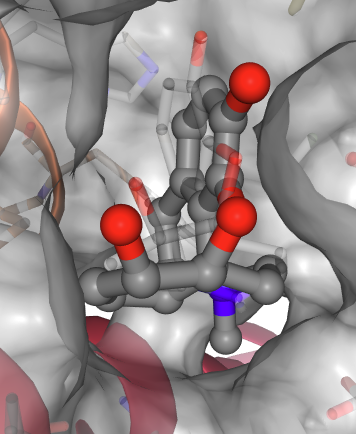

**And this is the end of the docking tutorial!**